In [92]:
import math
import time


In [93]:
import pandas as pd
df = pd.read_csv('data.csv')


df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

x =df.drop(columns = ['diagnosis'])
y = df['diagnosis']



In [94]:
print(x.isnull().sum())

id                           0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed: 32                569
dtype: i

In [95]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

In [96]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.2, random_state= 30)


x_train = x_train.values.tolist()
x_test = x_test.values.tolist()
y_train = y_train.values.tolist()
y_test = y_test.values.tolist()

now from here part 1 : from scratch

In [97]:



mean = []
std_devs = []
num_features = len(x_train[0])
num_rows = len(x_train)
for column in range (0,num_features):
  column_values= [ row[column] for row in x_train]
  column_mean = (sum(column_values)/num_rows)
  mean.append(column_mean)


  sum_sq_diff = sum((x-column_mean)**2 for x in column_values)
  column_variance = sum_sq_diff/num_rows
  column_std_dev = math.sqrt(column_variance)
  std_devs.append(column_std_dev)




In [98]:
x_train_scaled = []

for row_number in x_train:
  scaled_row = []
  for column_number in range(num_features):
    scaled_value = (row_number[column_number]-mean[column_number])/std_devs[column_number]
    scaled_row.append(scaled_value)
  x_train_scaled.append(scaled_row)

In [99]:
weights = [0.0]*num_features
bias = 0.0

In [100]:
def sigmoid(z):
  temp = 1/(1+math.exp(-z))
  return temp

In [101]:
def prediction (row , weight, bias):
  z = bias
  for i in range(0,num_features):
    temp = row[i]*weight[i]
    z = z + temp
  return sigmoid(z)

In [102]:
import math
def cost_function(x_train,y_train,weights,bias):
  num_rows = len(x_train)
  total_cost = 0.0
  for i in range(0,num_rows):
    row = x_train[i]
    prediction_value = prediction(row,weights,bias)
    actual_value = y_train[i]

    prediction_value = max(1e-15, min(1.0 - 1e-15, prediction_value))  #added this line of code after hitting math domain error

    cost = -(actual_value*math.log(prediction_value)+(1-actual_value)*math.log(1-prediction_value))
    total_cost += cost
  return total_cost/num_rows

In [103]:

def gradient_descent (x_train,y_train,weights,bias,learning_rate,epochs):
  num_rows = len(x_train)
  num_features = len(weights)

  loss_log = []

  for epoch in range (0,epochs):
    grad_weights = [0]*num_features
    grad_bias = 0





    for i in range (num_rows):
      row = x_train[i]
      y_actual = y_train[i]
      y_predicted = prediction(row, weights , bias)
      error=  (y_predicted - y_actual)


      grad_bias += error

      for j in range (num_features):
        grad_weights[j] += error*row[j]



    bias = bias- (learning_rate*(grad_bias/num_rows))
    for k in range (num_features):
      weights[k] = weights[k] - (learning_rate*(grad_weights[k]/num_rows))


    cost = cost_function(x_train,y_train, weights,bias)
    loss_log.append(cost)



    if epoch%10 == 0:
      print(f"Epoch {epoch} | Cost: {cost}")


  return weights , bias , loss_log


In [107]:
# Remove the last column (the 'nan' ghost column) from every row
x_train_clean = [row[:-1] for row in x_train_scaled]


num_features = len(x_train_clean[0])


my_weights = [0.0 for _ in range(num_features)]
my_bias = 0.0


learning_rate = 0.1
epochs = 500

trained_w, trained_b, loss_history = gradient_descent(
    x_train_clean,
    y_train,
    my_weights,
    my_bias,
    learning_rate,
    epochs
)

Epoch 0 | Cost: 0.5251868229094483
Epoch 10 | Cost: 0.23316726948608668
Epoch 20 | Cost: 0.17926889640312804
Epoch 30 | Cost: 0.15366630806369652
Epoch 40 | Cost: 0.13820624416971855
Epoch 50 | Cost: 0.12766859429224686
Epoch 60 | Cost: 0.11992941848332941
Epoch 70 | Cost: 0.11395034455638967
Epoch 80 | Cost: 0.1091592286110164
Epoch 90 | Cost: 0.10521276374474878
Epoch 100 | Cost: 0.10189133754859778
Epoch 110 | Cost: 0.09904728661784798
Epoch 120 | Cost: 0.09657728462145851
Epoch 130 | Cost: 0.09440663146212186
Epoch 140 | Cost: 0.09247983458190744
Epoch 150 | Cost: 0.09075471210801854
Epoch 160 | Cost: 0.08919856329185696
Epoch 170 | Cost: 0.0877856023790764
Epoch 180 | Cost: 0.08649519185159045
Epoch 190 | Cost: 0.0853105968858756
Epoch 200 | Cost: 0.08421808875105966
Epoch 210 | Cost: 0.08320628732859676
Epoch 220 | Cost: 0.08226567093858539
Epoch 230 | Cost: 0.08138820542644679
Epoch 240 | Cost: 0.08056705970017934
Epoch 250 | Cost: 0.07979638489450366
Epoch 260 | Cost: 0.0790711

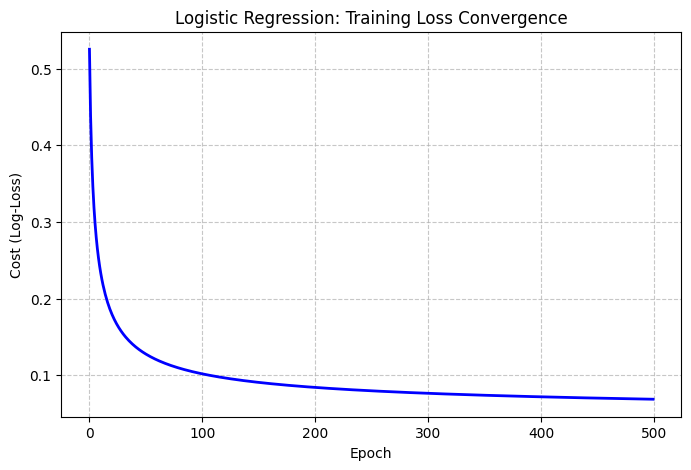

In [108]:
import matplotlib.pyplot as plt

# Plot the loss history
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', linewidth=2)

# Add titles and labels
plt.title("Logistic Regression: Training Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("Cost (Log-Loss)")
plt.grid(True, linestyle='--', alpha=0.7)

# Display the chart
plt.show()

In [109]:
# 1. Clean and Scale the Test Data
# Drop the ghost column
x_test_clean = [row[:-1] for row in x_test]

# Scale using the TRAINING mean and std_devs to prevent data leakage!
x_test_scaled = []
for row in x_test_clean:
    scaled_row = []
    for col_idx in range(num_features):
        # Using the mean and std_devs lists we generated way back in step 1
        scaled_value = (row[col_idx] - mean[col_idx]) / std_devs[col_idx]
        scaled_row.append(scaled_value)
    x_test_scaled.append(scaled_row)

# Ensure y_test is a pure Python list, just in case
if hasattr(y_test, 'values'):
    y_test_list = y_test.values.tolist()
else:
    y_test_list = y_test

# 2. Build the Confusion Matrix
TP = 0  # Predicted Malignant, Actually Malignant
TN = 0  # Predicted Benign, Actually Benign
FP = 0  # Predicted Malignant, Actually Benign (False Alarm)
FN = 0  # Predicted Benign, Actually Malignant (Missed Diagnosis)

for i in range(len(x_test_scaled)):
    row = x_test_scaled[i]
    actual = y_test_list[i]

    # Get the probability from our trained model
    prob = prediction(row, trained_w, trained_b)

    # Threshold at 50%
    pred_class = 1.0 if prob >= 0.5 else 0.0

    # Tally the results
    if pred_class == 1.0 and actual == 1.0:
        TP += 1
    elif pred_class == 0.0 and actual == 0.0:
        TN += 1
    elif pred_class == 1.0 and actual == 0.0:
        FP += 1
    elif pred_class == 0.0 and actual == 1.0:
        FN += 1

# 3. Calculate Final Performance Metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Safeguards against division by zero
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

# Print the final report
print("--- Confusion Matrix ---")
print(f"True Positives (TP):  {TP}")
print(f"True Negatives (TN):  {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print("\n--- Performance Metrics ---")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")

--- Confusion Matrix ---
True Positives (TP):  43
True Negatives (TN):  70
False Positives (FP): 0
False Negatives (FN): 1

--- Performance Metrics ---
Accuracy:  99.12%
Precision: 1.0000
Recall:    0.9773
F1-Score:  0.9885


part two

In [110]:
import numpy as np
x_train_np = np.array(x_train_clean)
y_train_np = np.array(y_train).reshape(-1,1)




In [111]:
def sigmoid_np(z):
  temp = 1/(1+np.exp(-z))
  return temp


In [112]:
def prediction_np(row , weights, bias):
  z= bias + (np.dot(row, weights))
  return sigmoid_np(z)

In [113]:
def cost_function_np(x_train_np, y_train_np,weights, bias ):
 predictions = prediction_np(x_train_np, weights, bias)
 preds_clamped = np.clip(predictions, 1e-15, 1.0 - 1e-15)
 cost = -np.mean((y_train_np * np.log(preds_clamped)) + ((1 - y_train_np) * np.log(1 - preds_clamped)))

 return cost





In [114]:
def gradient_descent_np(x_train_np, y_train_np, weights, bias, learning_rate, epochs):
  num_rows = x_train_np.shape[0]
  num_features = x_train_np.shape[1]
  loss_log = []
  for epoch in range (0,epochs):
    y_predicted = prediction_np(x_train_np, weights, bias)
    error = y_predicted - y_train_np
    grad_bias = np.mean(error)
    grad_weights = np.dot(x_train_np.T, error)/num_features
    bias = bias - (learning_rate*grad_bias)
    weights = weights - (learning_rate*grad_weights)
    cost = cost_function_np(x_train_np, y_train_np, weights, bias)
    loss_log.append(cost)
    if epoch % 10 == 0:
      print(f"Epoch {epoch} | Cost: {cost}")
  return weights, bias, loss_log

In [115]:

num_features = x_train_np.shape[1]
weights_np = np.zeros((num_features, 1))
bias_np = 0.0


learning_rate = 0.1
epochs = 500


trained_w_np, trained_b_np, loss_history_np = gradient_descent_np(
    x_train_np,
    y_train_np,
    weights_np,
    bias_np,
    learning_rate,
    epochs
)

Epoch 0 | Cost: 0.17354231999653613
Epoch 10 | Cost: 0.08105024595932908
Epoch 20 | Cost: 0.07309063223648556
Epoch 30 | Cost: 0.06839807506026228
Epoch 40 | Cost: 0.06513178645000416
Epoch 50 | Cost: 0.0626743520069308
Epoch 60 | Cost: 0.06073496671606206
Epoch 70 | Cost: 0.05915327466578678
Epoch 80 | Cost: 0.05783184879015313
Epoch 90 | Cost: 0.056707276601580474
Epoch 100 | Cost: 0.05573607238462315
Epoch 110 | Cost: 0.054887175097305715
Epoch 120 | Cost: 0.05413767206552318
Epoch 130 | Cost: 0.05347022027439705
Epoch 140 | Cost: 0.052871413645122205
Epoch 150 | Cost: 0.05233070432317957
Epoch 160 | Cost: 0.05183966364322088
Epoch 170 | Cost: 0.05139146055288807
Epoch 180 | Cost: 0.050980484986864326
Epoch 190 | Cost: 0.050602071454107805
Epoch 200 | Cost: 0.05025229408613448
Epoch 210 | Cost: 0.04992781382836417
Epoch 220 | Cost: 0.04962576416877866
Epoch 230 | Cost: 0.04934366539483231
Epoch 240 | Cost: 0.04907935979051614
Epoch 250 | Cost: 0.04883096196843743
Epoch 260 | Cost: 0

In [116]:
import time

print("Initiating Speed Test (500 Epochs)...")

# --- 1. Time the Pure Python Version ---
# Re-initialize fresh Python weights
my_weights_py = [0.0 for _ in range(num_features)]
bias_py = 0.0

start_py = time.time()
_ = gradient_descent(x_train_clean, y_train_list, my_weights_py, bias_py, 0.1, 500)
end_py = time.time()
time_py = end_py - start_py

# --- 2. Time the NumPy Version ---
# Re-initialize fresh NumPy weights
weights_np_test = np.zeros((num_features, 1))
bias_np_test = 0.0

start_np = time.time()
_ = gradient_descent_np(x_train_np, y_train_np, weights_np_test, bias_np_test, 0.1, 500)
end_np = time.time()
time_np = end_np - start_np

# --- 3. Print the Results ---
print(f"Pure Python Time: {time_py:.4f} seconds")
print(f"NumPy Time:       {time_np:.4f} seconds")

if time_np > 0:
    speedup = time_py / time_np
    print(f"\nResult: NumPy is {speedup:.1f}x faster!")

Initiating Speed Test (500 Epochs)...
Epoch 0 | Cost: 0.5251868229094483
Epoch 10 | Cost: 0.23316726948608668
Epoch 20 | Cost: 0.17926889640312804
Epoch 30 | Cost: 0.15366630806369652
Epoch 40 | Cost: 0.13820624416971855
Epoch 50 | Cost: 0.12766859429224686
Epoch 60 | Cost: 0.11992941848332941
Epoch 70 | Cost: 0.11395034455638967
Epoch 80 | Cost: 0.1091592286110164
Epoch 90 | Cost: 0.10521276374474878
Epoch 100 | Cost: 0.10189133754859778
Epoch 110 | Cost: 0.09904728661784798
Epoch 120 | Cost: 0.09657728462145851
Epoch 130 | Cost: 0.09440663146212186
Epoch 140 | Cost: 0.09247983458190744
Epoch 150 | Cost: 0.09075471210801854
Epoch 160 | Cost: 0.08919856329185696
Epoch 170 | Cost: 0.0877856023790764
Epoch 180 | Cost: 0.08649519185159045
Epoch 190 | Cost: 0.0853105968858756
Epoch 200 | Cost: 0.08421808875105966
Epoch 210 | Cost: 0.08320628732859676
Epoch 220 | Cost: 0.08226567093858539
Epoch 230 | Cost: 0.08138820542644679
Epoch 240 | Cost: 0.08056705970017934
Epoch 250 | Cost: 0.0797963

In [117]:
def calculate_roc_auc(y_actual, y_probabilities):
    # Pair up probabilities with actual labels and sort them highest to lowest
    data = sorted(zip(y_probabilities, y_actual), key=lambda x: x[0], reverse=True)

    num_positives = sum(y_actual)
    num_negatives = len(y_actual) - num_positives

    auc = 0.0
    accumulated_tp = 0

    # Calculate the area under the curve using the rank-order method
    for prob, actual in data:
        if actual == 1.0:
            accumulated_tp += 1
        else:
            auc += accumulated_tp

    # Normalize by total possible area
    return auc / (num_positives * num_negatives)

# Calculate probabilities for the test set
y_test_probs = [prediction(row, trained_w, trained_b) for row in x_test_scaled]

# Get the final score!
roc_auc_score = calculate_roc_auc(y_test_list, y_test_probs)
print(f"ROC-AUC Score: {roc_auc_score:.4f}")

ROC-AUC Score: 0.9977


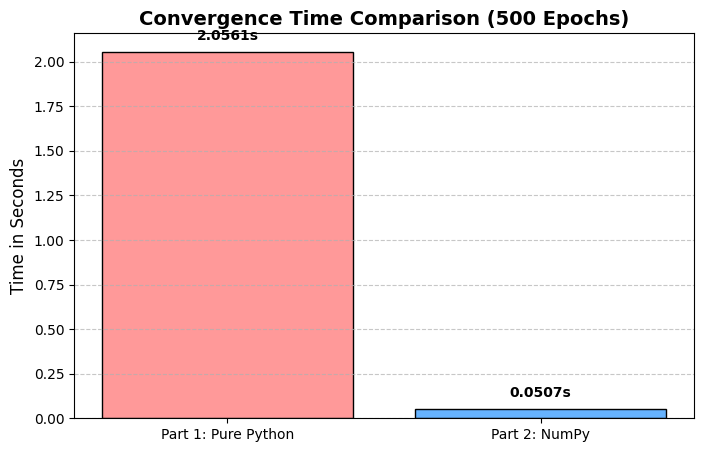

In [118]:
import matplotlib.pyplot as plt

# The times we recorded earlier
methods = ['Part 1: Pure Python', 'Part 2: NumPy']
times = [2.0561, 0.0507]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, times, color=['#ff9999', '#66b3ff'], edgecolor='black')

# Add titles and labels
plt.title('Convergence Time Comparison (500 Epochs)', fontsize=14, fontweight='bold')
plt.ylabel('Time in Seconds', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval}s", ha='center', va='bottom', fontweight='bold')

plt.show()